In [2]:
### Importing necessary libraries
import argparse

import EoN
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import seaborn as sns
import xgi

# from joblib import Parallel, delayed

from src import *

set_fonts()

In [ ]:
### Empty list to store results from the loop
results = []

### Parameters
N = 10000
k = 10

### Building combinations for e and r
e_vals = np.round(np.arange(0.1, 1.0, 0.1), 2)  # 0.8
r_vals = np.round(np.arange(0.1, 1.0, 0.1), 2)  # 0.5
combinations = [(i, j) for i in e_vals for j in r_vals]

### Parse job id
parser = argparse.ArgumentParser()
parser.add_argument("--job_id", type=int)
args = parser.parse_args()

e, r = combinations[args.job_id]

### Setting a base gamma
gam = 0.1

args = {"N": N, "k": k, "e": e, "r": r, "gam": gam}


def run_epidemic(R0, real, args):
    ### Redefining params
    N = args["N"]
    k = args["k"]
    e = args["e"]
    r = args["r"]
    gam = args["gam"]

    ### Setting the community sizes
    size_comm1 = int(r * N)
    size_comm2 = int(N - size_comm1)

    ### Defining the range for eps and del
    eps = np.linspace(0.1, 3, 100)
    dels = np.linspace(0.1, 3, 100)

    ### Creating the distributions and population
    joint_dist1, comm1 = create_comm(0.8, samplesize=size_comm1)
    joint_dist2, comm2 = create_comm(-0.8, samplesize=size_comm2)

    ### Store the eps and dels for each individual in a population array
    population = np.concatenate([comm1, comm2], axis=0)

    ### Setting beta based on the R0 and gamma
    a = eps @ joint_dist1 @ dels.T
    b = eps @ joint_dist2 @ dels.T

    beta = IBC_beta(a, b, R0, gam, k, e, r)

    ### Create the graph
    G = xgi.uniform_HPPM(N, 2, k, e, r)
    G = xgi.convert.to_graph(G)
    G = nx.DiGraph(G)

    ### Assign each edge the transmission probability
    e_attr = dict()
    for i, j in G.edges:
        e_attr[(i, j)] = {"weights": population[i][1] * population[j][0]}
    nx.set_edge_attributes(G, e_attr)

    ### Seed the initial infected as a small percent of total population
    first_infected = np.random.choice(
        range(0, size_comm1), size=int(N * 0.001), replace=False
    )

    ### Run EoN.fast_SIR
    sim = EoN.fast_SIR(
        G,
        beta,
        gam,
        initial_infecteds=first_infected,
        transmission_weight="weights",
        return_full_data=True,
    )

    ### Find nodes which were in comm1 and comm2
    node_list_comm1 = list(range(0, size_comm1))
    node_list_comm2 = list(range(size_comm1, size_comm1 + size_comm2))

    ### Extract data from simulation summary
    _, D1 = sim.summary(node_list_comm1)
    _, D2 = sim.summary(node_list_comm2)

    ### Store results
    return {
        "real": real,
        "R0": R0,
        "R1": D1["R"][-1] / size_comm1,
        "R2": D2["R"][-1] / size_comm2,
        "Rt": (D1["R"][-1] + D2["R"][-1]) / N,
    }


n_cores = 64

results = Parallel(n_jobs=n_cores)(
    delayed(run_epidemic)(R0, real, args)
    for R0 in np.linspace(0.5, 3.0, 1000)
    for real in range(100)
)

### Create a csv file to store results
pl.DataFrame(results).write_csv(f"Data/Fig3_e_{e:.2f}_r_{r:.2f}_RandomData.csv")

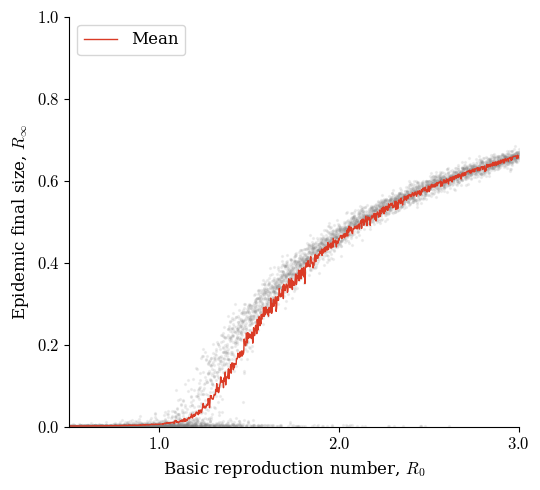

In [ ]:
e = 0.8
r = 0.8

filepath = f"Data/Fig3_e_{e:.2f}_r_{r:.2f}_RandomData.csv"

results_fig3 = pl.read_csv(filepath)
results_median = results_fig3.group_by("R0").agg(pl.mean("Rt")).sort("R0")

fig = plt.figure(figsize=(5.5, 5))
plt.scatter(
    results_fig3["R0"][::20], results_fig3["Rt"][::20], alpha=0.1, color="grey", s=2
)
plt.plot(
    results_median["R0"],
    results_median["Rt"],
    linewidth=1,
    color="#DA3B26",
    label="Mean",
)

plt.xlabel(r"Basic reproduction number, $R_0$")
plt.ylabel(r"Epidemic final size, $R_\infty$")

plt.xticks([1.0, 2.0, 3.0], labels=[r"$1.0$", r"$2.0$", r"$3.0$"])
plt.yticks(
    np.linspace(0.0, 1.0, 6),
    labels=[r"$0.0$", r"$0.2$", r"$0.4$", r"$0.6$", r"$0.8$", r"$1.0$"],
)

plt.xlim(0.5, 3.0)
plt.ylim(0.0, 1.0)
plt.legend(loc="upper left")

sns.despine()
plt.tight_layout()

plt.savefig("Figures/Figure-2.png", dpi=1000)
plt.savefig("Figures/Figure-2.svg", format="svg")
plt.savefig("Figures/Figure-2.pdf", format="pdf")